PHASE 1: LOADING DATA
Application Train Shape: (307511, 122)
Bureau Shape: (1716428, 17)
Bureau Balance Shape: (27299925, 3)
Previous Application Shape: (1670214, 37)
POS Cash Shape: (10001358, 8)
Installments Shape: (13605401, 8)
Credit Card Shape: (3840312, 23)

PHASE 2: EXPLORATORY DATA ANALYSIS

Target Variable Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Imbalance Ratio:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

PHASE 3: DATA PREPROCESSING - FEATURE CONCATENATION
Shape after feature concatenation: (307511, 317)
Total features: 316

PHASE 4: HANDLING MISSING VALUES
Columns with >30% missing values: 110
Columns removed: 110
Shape after removing missing columns: (307511, 207)

PHASE 5: FEATURE ENCODING & NORMALIZATION
Categorical columns: 11
Shape after encoding: (307511, 205)
Data normalized and scaled

PHASE 6: HANDLING CLASS IMBALANCE - DOWN-SAMPLING
Before down-sampling - Target distribution:
TARGET
0    282686
1     24

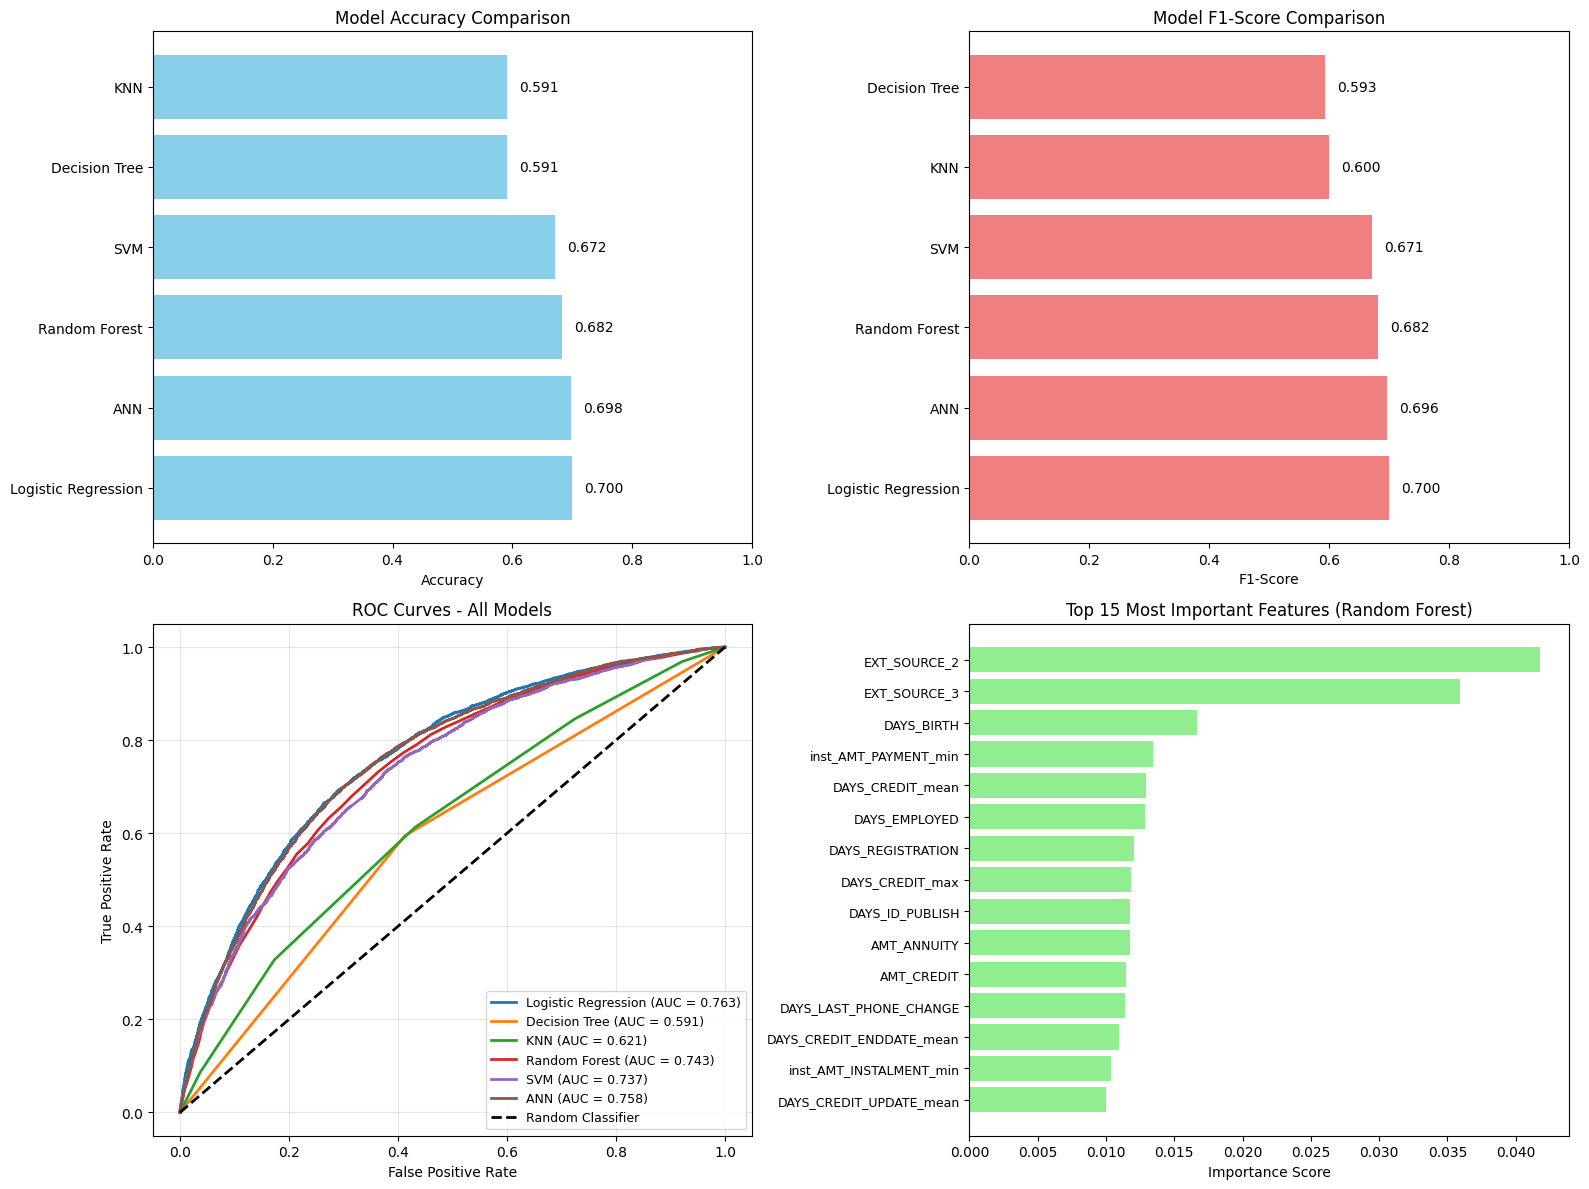


FINAL SUMMARY

✓ Best Model (Accuracy): Logistic Regression (0.6997)
✓ Best Model (F1-Score): Logistic Regression (0.7004)
✓ Best Model (ROC-AUC): Logistic Regression (0.7629)

✓ Single Model (Logistic Regression) Accuracy: 0.6997
✓ Cluster-based approach Accuracy: 0.6931
✓ Improvement: -0.0066

✓ Most Important Feature: EXT_SOURCE_2 (Importance: 0.0418)
✓ Second Important Feature: EXT_SOURCE_3 (Importance: 0.0359)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ===================== SET OUTPUT PATH =====================
OUTPUT_PATH = r"C:\Users\shrey\Desktop\ML"
os.makedirs(OUTPUT_PATH, exist_ok=True)

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time

# ===================== 1. LOAD DATA =====================
print("=" * 80)
print("PHASE 1: LOADING DATA")
print("=" * 80)

base_path = r"C:\Users\shrey\Desktop\ML"

# Load all CSV files
app_train = pd.read_csv(f"{base_path}/application_train.csv")
bureau = pd.read_csv(f"{base_path}/bureau.csv")
bureau_balance = pd.read_csv(f"{base_path}/bureau_balance.csv")
prev_app = pd.read_csv(f"{base_path}/previous_application.csv")
pos_cash = pd.read_csv(f"{base_path}/POS_CASH_balance.csv")
installments = pd.read_csv(f"{base_path}/installments_payments.csv")
credit_card = pd.read_csv(f"{base_path}/credit_card_balance.csv")

print(f"Application Train Shape: {app_train.shape}")
print(f"Bureau Shape: {bureau.shape}")
print(f"Bureau Balance Shape: {bureau_balance.shape}")
print(f"Previous Application Shape: {prev_app.shape}")
print(f"POS Cash Shape: {pos_cash.shape}")
print(f"Installments Shape: {installments.shape}")
print(f"Credit Card Shape: {credit_card.shape}")

# ===================== 2. EXPLORATORY DATA ANALYSIS =====================
print("\n" + "=" * 80)
print("PHASE 2: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

print(f"\nTarget Variable Distribution:")
print(app_train['TARGET'].value_counts())
print(f"\nTarget Imbalance Ratio:")
print(app_train['TARGET'].value_counts(normalize=True))

# ===================== 3. DATA PREPROCESSING =====================
print("\n" + "=" * 80)
print("PHASE 3: DATA PREPROCESSING - FEATURE CONCATENATION")
print("=" * 80)

# Aggregate bureau balance first, then merge with bureau
bureau_bal_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    col: ['mean', 'max', 'min'] for col in bureau_balance.select_dtypes(include=[np.number]).columns
    if col != 'SK_ID_BUREAU'
}).fillna(0)
bureau_bal_agg.columns = ['_'.join(col).strip() for col in bureau_bal_agg.columns.values]
bureau_bal_agg = bureau_bal_agg.reset_index()

# Merge bureau with bureau_balance
bureau_merged = bureau.merge(bureau_bal_agg, on='SK_ID_BUREAU', how='left')

# Aggregate merged bureau data by SK_ID_CURR
bureau_agg = bureau_merged.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in bureau_merged.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_BUREAU']
}).fillna(0)
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg = bureau_agg.reset_index()

# Aggregate previous applications
prev_agg = prev_app.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in prev_app.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']
}).fillna(0)
prev_agg.columns = ['prev_' + '_'.join(col).strip() for col in prev_agg.columns.values]
prev_agg = prev_agg.reset_index()

# Aggregate POS cash balance
pos_agg = pos_cash.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in pos_cash.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']
}).fillna(0)
pos_agg.columns = ['pos_' + '_'.join(col).strip() for col in pos_agg.columns.values]
pos_agg = pos_agg.reset_index()

# Aggregate installments
inst_agg = installments.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in installments.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_PREV', 'SK_ID_INST']
}).fillna(0)
inst_agg.columns = ['inst_' + '_'.join(col).strip() for col in inst_agg.columns.values]
inst_agg = inst_agg.reset_index()

# Aggregate credit card balance
cc_agg = credit_card.groupby('SK_ID_CURR').agg({
    col: ['mean', 'max', 'min'] for col in credit_card.select_dtypes(include=[np.number]).columns
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']
}).fillna(0)
cc_agg.columns = ['cc_' + '_'.join(col).strip() for col in cc_agg.columns.values]
cc_agg = cc_agg.reset_index()

# Merge all features
df = app_train.copy()
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
df = df.merge(prev_agg, on='SK_ID_CURR', how='left')
df = df.merge(pos_agg, on='SK_ID_CURR', how='left')
df = df.merge(inst_agg, on='SK_ID_CURR', how='left')
df = df.merge(cc_agg, on='SK_ID_CURR', how='left')

print(f"Shape after feature concatenation: {df.shape}")
print(f"Total features: {df.shape[1] - 1}")  # Exclude TARGET

# ===================== 4. HANDLE MISSING VALUES =====================
print("\n" + "=" * 80)
print("PHASE 4: HANDLING MISSING VALUES")
print("=" * 80)

# Calculate missing value percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
print(f"Columns with >30% missing values: {(missing_pct > 30).sum()}")

# Remove columns with >30% missing
cols_to_drop = missing_pct[missing_pct > 30].index
df = df.drop(columns=cols_to_drop)
print(f"Columns removed: {len(cols_to_drop)}")

# Fill remaining missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print(f"Shape after removing missing columns: {df.shape}")

# ===================== 5. FEATURE ENCODING =====================
print("\n" + "=" * 80)
print("PHASE 5: FEATURE ENCODING & NORMALIZATION")
print("=" * 80)

# Separate target and features
X = df.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = df['TARGET']

# Handle categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Categorical columns: {len(categorical_cols)}")

# Label encode categorical variables
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

print(f"Shape after encoding: {X.shape}")

# ===================== 6. NORMALIZATION =====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Data normalized and scaled")

# ===================== 7. CLASS IMBALANCE - DOWN-SAMPLING =====================
print("\n" + "=" * 80)
print("PHASE 6: HANDLING CLASS IMBALANCE - DOWN-SAMPLING")
print("=" * 80)

print(f"Before down-sampling - Target distribution:")
print(y.value_counts())

# Separate majority and minority classes
X_neg = X_scaled[y == 0]
X_pos = X_scaled[y == 1]
y_neg = y[y == 0]
y_pos = y[y == 1]

# Down-sample majority class
np.random.seed(42)
neg_idx = np.random.choice(X_neg.index, size=len(X_pos), replace=False)
X_balanced = pd.concat([X_pos, X_neg.loc[neg_idx]])
y_balanced = pd.concat([y_pos, y_neg.loc[neg_idx]])

print(f"After down-sampling - Target distribution:")
print(y_balanced.value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"\nTrain set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# ===================== 8. MODEL TRAINING & EVALUATION =====================
print("\n" + "=" * 80)
print("PHASE 7: MODEL TRAINING & EVALUATION")
print("=" * 80)

results = []

# 1. Logistic Regression
print("\n[1/6] Training Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]
lr_time = time.time() - start

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lr),
    'Time(s)': lr_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}, Time: {lr_time:.2f}s")

# 2. Decision Tree
print("[2/6] Training Decision Tree...")
start = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]
dt_time = time.time() - start

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_dt),
    'Time(s)': dt_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}, Time: {dt_time:.2f}s")

# 3. KNN
print("[3/6] Training K-Nearest Neighbors...")
start = time.time()
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_pred_proba_knn = knn.predict_proba(X_test)[:, 1]
knn_time = time.time() - start

results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_knn),
    'Time(s)': knn_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}, Time: {knn_time:.2f}s")

# 4. Random Forest
print("[4/6] Training Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
rf_time = time.time() - start

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf),
    'Time(s)': rf_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}, Time: {rf_time:.2f}s")

# 5. SVM (with reduced dataset for faster training)
print("[5/6] Training Support Vector Machine...")
start = time.time()
# SVM doesn't scale well, so use a sample for faster training
sample_size = min(5000, len(X_train))
sample_idx = np.random.choice(X_train.index, size=sample_size, replace=False)
X_train_sample = X_train.loc[sample_idx]
y_train_sample = y_train.loc[sample_idx]

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_sample, y_train_sample)
y_pred_svm = svm.predict(X_test)
y_pred_proba_svm = svm.predict_proba(X_test)[:, 1]
svm_time = time.time() - start

results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1-Score': f1_score(y_test, y_pred_svm),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_svm),
    'Time(s)': svm_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}, Time: {svm_time:.2f}s")

# 6. Artificial Neural Network
print("[6/6] Training Artificial Neural Network...")
start = time.time()

# Build ANN model
ann = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train ANN
ann.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0, validation_split=0.2)
y_pred_proba_ann = ann.predict(X_test, verbose=0).flatten()
y_pred_ann = (y_pred_proba_ann > 0.5).astype(int)
ann_time = time.time() - start

results.append({
    'Model': 'ANN',
    'Accuracy': accuracy_score(y_test, y_pred_ann),
    'Precision': precision_score(y_test, y_pred_ann),
    'Recall': recall_score(y_test, y_pred_ann),
    'F1-Score': f1_score(y_test, y_pred_ann),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_ann),
    'Time(s)': ann_time
})
print(f"✓ Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1-Score']:.4f}, Time: {ann_time:.2f}s")

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON ")
print("=" * 80)
print(results_df.to_string(index=False))

# ===================== 9. K-MEANS CLUSTERING =====================
print("\n" + "=" * 80)
print("PHASE 8: K-MEANS CLUSTERING & CLUSTER-SPECIFIC MODELS")
print("=" * 80)

# Apply K-means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X_balanced_np = X_balanced.values
clusters = kmeans.fit_predict(X_balanced_np)
X_balanced['Cluster'] = clusters

print(f"Cluster distribution:")
print(X_balanced['Cluster'].value_counts().sort_index())

# Train models on each cluster
cluster_results = []

for cluster_id in range(4):
    X_cluster_train = X_train[X_train.index.isin(X_balanced[X_balanced['Cluster'] == cluster_id].index)]
    y_cluster_train = y_train[y_train.index.isin(X_balanced[X_balanced['Cluster'] == cluster_id].index)]
    
    X_cluster_test = X_test[X_test.index.isin(X_balanced[X_balanced['Cluster'] == cluster_id].index)]
    y_cluster_test = y_test[y_test.index.isin(X_balanced[X_balanced['Cluster'] == cluster_id].index)]
    
    if len(X_cluster_train) > 10 and len(X_cluster_test) > 10:
        # Train Logistic Regression on cluster
        lr_cluster = LogisticRegression(max_iter=1000, random_state=42)
        lr_cluster.fit(X_cluster_train, y_cluster_train)
        y_pred_cluster = lr_cluster.predict(X_cluster_test)
        y_pred_proba_cluster = lr_cluster.predict_proba(X_cluster_test)[:, 1]
        
        # Calculate metrics for both classes
        accuracy = accuracy_score(y_cluster_test, y_pred_cluster)
        
        # Precision for class 0 and class 1
        precision_scores = precision_score(y_cluster_test, y_pred_cluster, labels=[0, 1], average=None, zero_division=0)
        precision_str = f"{precision_scores[0]:.2f}/{precision_scores[1]:.2f}"
        
        # Recall for class 0 and class 1
        recall_scores = recall_score(y_cluster_test, y_pred_cluster, labels=[0, 1], average=None, zero_division=0)
        recall_str = f"{recall_scores[0]:.2f}/{recall_scores[1]:.2f}"
        
        # F1-Score for class 0 and class 1
        f1_scores = f1_score(y_cluster_test, y_pred_cluster, labels=[0, 1], average=None, zero_division=0)
        f1_str = f"{f1_scores[0]:.2f}/{f1_scores[1]:.2f}"
        
        cluster_results.append({
            'Cluster': f'Cluster {cluster_id + 1}',
            'Accuracy': f"{accuracy:.2%}",
            'Precision': precision_str,
            'Recall': recall_str,
            'F1-Score': f1_str
        })

# Add Overall row (average across all clusters)
if cluster_results:
    # Parse and average the numeric values
    acc_values = [float(r['Accuracy'].strip('%'))/100 for r in cluster_results]
    prec_0_values = [float(r['Precision'].split('/')[0]) for r in cluster_results]
    prec_1_values = [float(r['Precision'].split('/')[1]) for r in cluster_results]
    recall_0_values = [float(r['Recall'].split('/')[0]) for r in cluster_results]
    recall_1_values = [float(r['Recall'].split('/')[1]) for r in cluster_results]
    f1_0_values = [float(r['F1-Score'].split('/')[0]) for r in cluster_results]
    f1_1_values = [float(r['F1-Score'].split('/')[1]) for r in cluster_results]
    
    overall_row = {
        'Cluster': 'Overall',
        'Accuracy': f"{np.mean(acc_values):.2%}",
        'Precision': f"{np.mean(prec_0_values):.2f}/{np.mean(prec_1_values):.2f}",
        'Recall': f"{np.mean(recall_0_values):.2f}/{np.mean(recall_1_values):.2f}",
        'F1-Score': f"{np.mean(f1_0_values):.2f}/{np.mean(f1_1_values):.2f}"
    }
    cluster_results.append(overall_row)

cluster_results_df = pd.DataFrame(cluster_results)

print("\n" + "=" * 80)
print("PERFORMANCE OF K-MEANS CLUSTERING WITH CLASSIFICATION ALGORITHMS")
print("=" * 80)
print(cluster_results_df.to_string(index=False))

# ===================== 10. FEATURE IMPORTANCE =====================
print("\n" + "=" * 80)
print("PHASE 9: FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# ===================== 11. VISUALIZATIONS =====================
print("\n" + "=" * 80)
print("PHASE 10: GENERATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model Accuracy Comparison
ax1 = axes[0, 0]
results_df_sorted = results_df.sort_values('Accuracy', ascending=False)
ax1.barh(results_df_sorted['Model'], results_df_sorted['Accuracy'], color='skyblue')
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlim(0, 1)
for i, v in enumerate(results_df_sorted['Accuracy']):
    ax1.text(v + 0.02, i, f'{v:.3f}', va='center')

# 2. F1-Score Comparison
ax2 = axes[0, 1]
results_df_sorted_f1 = results_df.sort_values('F1-Score', ascending=False)
ax2.barh(results_df_sorted_f1['Model'], results_df_sorted_f1['F1-Score'], color='lightcoral')
ax2.set_xlabel('F1-Score')
ax2.set_title('Model F1-Score Comparison')
ax2.set_xlim(0, 1)
for i, v in enumerate(results_df_sorted_f1['F1-Score']):
    ax2.text(v + 0.02, i, f'{v:.3f}', va='center')

# 3. ROC Curves
ax3 = axes[1, 0]
models_predictions = [
    ('Logistic Regression', y_pred_proba_lr),
    ('Decision Tree', y_pred_proba_dt),
    ('KNN', y_pred_proba_knn),
    ('Random Forest', y_pred_proba_rf),
    ('SVM', y_pred_proba_svm),
    ('ANN', y_pred_proba_ann)
]

for name, y_pred_proba in models_predictions:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    ax3.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax3.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves - All Models')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Top 15 Feature Importance
ax4 = axes[1, 1]
top_features = feature_importance.head(15)
ax4.barh(range(len(top_features)), top_features['Importance'].values, color='lightgreen')
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features['Feature'].values, fontsize=9)
ax4.set_xlabel('Importance Score')
ax4.set_title('Top 15 Most Important Features (Random Forest)')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig(r'C:\Users\shrey\Desktop\ML\model_performance_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualizations saved to: C:\\Users\\shrey\\Desktop\\ML\\model_performance_analysis.png")
plt.show()

# ===================== 12. SUMMARY =====================
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\n✓ Best Model (Accuracy): {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"✓ Best Model (F1-Score): {results_df.loc[results_df['F1-Score'].idxmax(), 'Model']} ({results_df['F1-Score'].max():.4f})")
print(f"✓ Best Model (ROC-AUC): {results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']} ({results_df['ROC-AUC'].max():.4f})")

# Get overall cluster accuracy
overall_cluster_acc = cluster_results_df[cluster_results_df['Cluster'] == 'Overall']['Accuracy'].values[0]
overall_cluster_acc_float = float(overall_cluster_acc.strip('%')) / 100

lr_accuracy = results_df.loc[results_df['Model']=='Logistic Regression', 'Accuracy'].values[0]

print(f"\n✓ Single Model (Logistic Regression) Accuracy: {lr_accuracy:.4f}")
print(f"✓ Cluster-based approach Accuracy: {overall_cluster_acc_float:.4f}")
print(f"✓ Improvement: {(overall_cluster_acc_float - lr_accuracy):.4f}")

print(f"\n✓ Most Important Feature: {feature_importance.iloc[0]['Feature']} (Importance: {feature_importance.iloc[0]['Importance']:.4f})")
print(f"✓ Second Important Feature: {feature_importance.iloc[1]['Feature']} (Importance: {feature_importance.iloc[1]['Importance']:.4f})")
print("\n" + "=" * 80)